# Baseline Experiment - Binary Classification - BERTweet

Apply BERTweet to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [14]:
from pathlib import Path
# import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import Dataset, load_from_disk, load_dataset

import configuration
from src import setup


In [15]:
device = setup.setup_device_with_seeds()

Using device: mps


## B. Data Loading

In [16]:
# Convert to Hugging Face Datasets
train_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_BERTweet_normalized_train.csv")
)
val_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_BERTweet_normalized_validation.csv")
)
test_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_BERTweet_normalized_test.csv")
)

## C. Tokenization

In [17]:
# https://huggingface.co/vinai/bertweet-base
# vinai/bertweet-base - 135M
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base")

def tokenize_function(examples):
    return tokenizer(
        examples["tweet_text"], 
        padding="max_length", 
        truncation=True, # tweet_text is normally short
        max_length=64
    )

### C.1. Quick preview on dataset to find optimal parameter for `tokenizer`

In [18]:
quickview_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_normalized_train.csv").sample(2000, random_state=42)
)

token_lengths = [len(tokenizer.tokenize(text)) for text in quickview_ds["tweet_text"]]

df_lengths = pd.DataFrame({'length': token_lengths})

print("90th percentile:", df_lengths['length'].quantile(0.90))
print("95th percentile:", df_lengths['length'].quantile(0.95))
print("99th percentile:", df_lengths['length'].quantile(0.99))
print("Absolute Maximum length:", df_lengths['length'].max())

90th percentile: 37.0
95th percentile: 49.0
99th percentile: 63.0
Absolute Maximum length: 266


So, set the `max_length` to `64`.

### C.2. Do the Tokenization

In [19]:
train_tokenized_path = Path("../tokens/BERTweet/train_tokenized")
validation_tokenized_path = Path("../tokens/BERTweet/val_tokenized")
test_tokenized_path = Path("../tokens/BERTweet/test_tokenized")

#### Actually do to task

In [20]:
def format_dataset(dataset):
    # The HF Trainer API expects strictly the named `labels`
    # Rename target column to 'labels'
    dataset = dataset.rename_column("relevant", "labels")
    
    # Cast boolean values to integers (True -> 1, False -> 0)
    dataset = dataset.map(lambda x: {"labels": int(x["labels"])})
    
    # Set PyTorch tensor format for the required columns
    dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return dataset

# Apply in batches for efficiency
train_tokenized = format_dataset(
    train_ds.map(tokenize_function, batched=True))
val_tokenized = format_dataset(
    val_ds.map(tokenize_function, batched=True))
test_tokenized = format_dataset(
    test_ds.map(tokenize_function, batched=True))

Map: 100%|██████████| 25924/25924 [00:00<00:00, 40694.71 examples/s]


In [21]:
# Save individual datasets to a specified directory
train_tokenized.save_to_disk(train_tokenized_path)
val_tokenized.save_to_disk(validation_tokenized_path)
test_tokenized.save_to_disk(test_tokenized_path)

Saving the dataset (1/1 shards): 100%|██████████| 25924/25924 [00:00<00:00, 907887.42 examples/s]


#### Or Load the pre-processed Tokenization data

In [22]:
# train_tokenized = load_from_disk(train_tokenized_path)
# val_tokenized = load_from_disk(validation_tokenized_path)
# test_tokenized = load_from_disk(test_tokenized_path)

## B. Fine-tuning BERT

### B.0. Shrink dataset size for development purpose

In [23]:
# Comment out this cell to use the full dataset. This is just for quick testing.
train_size = 1000
train_tokenized = train_tokenized.select(range(train_size))
val_tokenized = val_tokenized.select(range(int(train_size / 4)))
test_tokenized = test_tokenized.select(range(int(train_size / 4)))

### B.1. Preparation

In [24]:
batch_size = 16
learning_rate = 5e-5

In [25]:
train_loader = DataLoader(train_tokenized, batch_size=batch_size, shuffle=True)
eval_loader = DataLoader(val_tokenized, batch_size=batch_size)

# Optimizer
num_labels = 2  # e.g., binary classification
bertweet = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base", num_labels=num_labels
)
bertweet.config.problem_type = "single_label_classification"
optimizer = AdamW(bertweet.parameters(), lr=learning_rate)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### B.2. Fine-tune

In [26]:
best_val_loss = float("inf")
best_state_dict = None
epochs_without_improvement = 0

train_loss_history = []
val_loss_history = []
val_acc_history = []

num_epochs = 5
patience = 2  # early stopping, if validation loss does not improve for this many epochs

bertweet.to(device)
for epoch in range(num_epochs):
    # Training
    bertweet.train()
    running_train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device)
        }
        labels = batch['labels'].to(device).view(-1).long()

        outputs = bertweet(**inputs, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Validation at end of each epoch
    bertweet.eval()
    correct = 0
    total = 0
    eval_losses = []

    with torch.no_grad():
        for batch in tqdm(eval_loader, desc=f"Validating Epoch {epoch+1}/{num_epochs}"):
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            labels = batch['labels'].to(device).view(-1).long()

            outputs = bertweet(**inputs, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            eval_losses.append(loss.item())
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = sum(eval_losses) / len(eval_losses)
    accuracy = correct / total
    val_loss_history.append(avg_loss)
    val_acc_history.append(accuracy)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_loss:.4f} | "
        f"Val Acc: {accuracy:.4f}"
    )

    # Early stopping + keep best model weights
    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        best_state_dict = {k: v.detach().cpu().clone() for k, v in bertweet.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

# Restore best model before test prediction
if best_state_dict is not None:
    bertweet.load_state_dict(best_state_dict)
    bertweet.to(device)
    print(f"Loaded best model with Val Loss: {best_val_loss:.4f}")

Validating Epoch 1/5: 100%|██████████| 16/16 [00:03<00:00,  4.91it/s]


Epoch 1/5 | Train Loss: 0.2813 | Val Loss: 0.3304 | Val Acc: 0.8840


Validating Epoch 2/5: 100%|██████████| 16/16 [00:02<00:00,  7.35it/s]


Epoch 2/5 | Train Loss: 0.1739 | Val Loss: 0.2840 | Val Acc: 0.8960


Validating Epoch 3/5: 100%|██████████| 16/16 [00:02<00:00,  7.44it/s]


Epoch 3/5 | Train Loss: 0.1332 | Val Loss: 0.2641 | Val Acc: 0.8920


Validating Epoch 4/5: 100%|██████████| 16/16 [00:02<00:00,  6.92it/s]


Epoch 4/5 | Train Loss: 0.0934 | Val Loss: 0.3078 | Val Acc: 0.8880


Validating Epoch 5/5: 100%|██████████| 16/16 [00:02<00:00,  7.44it/s]


Epoch 5/5 | Train Loss: 0.0653 | Val Loss: 0.3058 | Val Acc: 0.9120
Early stopping triggered at epoch 5.
Loaded best model with Val Loss: 0.2641


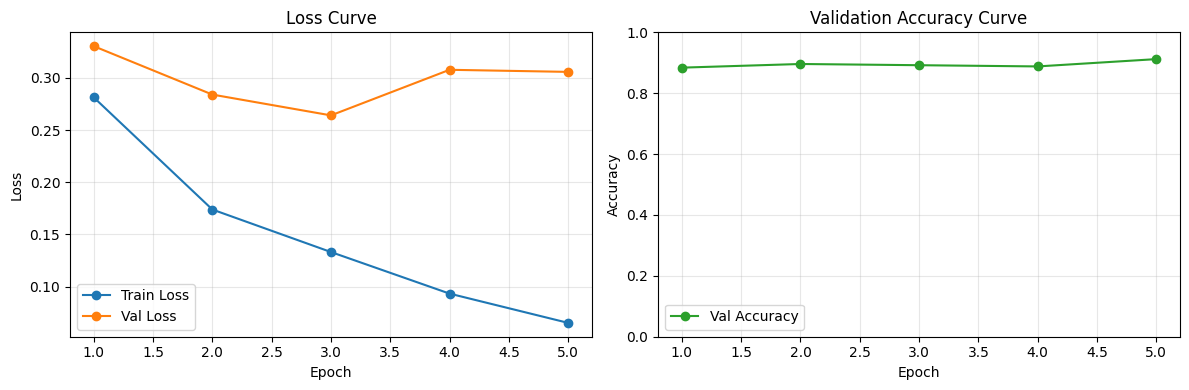

In [27]:
import matplotlib.pyplot as plt

if len(train_loss_history) == 0 or len(val_loss_history) == 0:
    print("No training history found. Run the fine-tuning cell first.")
else:
    epochs = range(1, len(train_loss_history) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, train_loss_history, marker='o', label='Train Loss')
    axes[0].plot(epochs, val_loss_history, marker='o', label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, val_acc_history, marker='o', color='tab:green', label='Val Accuracy')
    axes[1].set_title('Validation Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### B.3. Predict on the Test set

In [29]:
test_loader = DataLoader(test_tokenized, batch_size=batch_size)

bertweet.eval()
all_logits = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device)
        }
        outputs = bertweet(**inputs)
        all_logits.append(outputs.logits.cpu())

predictions = torch.cat(all_logits, dim=0).numpy()
test_preds = np.argmax(predictions, axis=-1)

Predicting: 100%|██████████| 16/16 [00:03<00:00,  5.02it/s]


In [30]:
if 'labels' in test_tokenized.column_names:
    y_true = np.array(test_tokenized['labels']).astype(int)
    y_pred = np.array(test_preds).astype(int)

    print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Test F1 (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
else:
    print("No 'labels' column found in test_tokenized. Metrics cannot be computed.")

Test Accuracy: 0.7960
Test F1 (macro): 0.7047

Classification report:
              precision    recall  f1-score   support

           0     0.4167    0.7692    0.5405        39
           1     0.9494    0.8009    0.8689       211

    accuracy                         0.7960       250
   macro avg     0.6831    0.7851    0.7047       250
weighted avg     0.8663    0.7960    0.8177       250

